# 01 — 原始数据探索 + 基准线建立

本 Notebook 完成三件事：
1. **Cell Group A**：探索原始 WARC 数据的结构和分布
2. **Cell Group B**：对比 Trafilatura vs Justext 文本提取器
3. **Cell Group C**：建立所有评估指标的基准线（未过滤数据）

## Cell Group A: 原始数据探索

In [1]:
# === 环境初始化与配置加载 ===
# 导入核心依赖：pandas/numpy 用于数据处理，matplotlib 用于可视化
# 设置中文字体以确保图表中的中文标签正常显示
# 通过 config_loader 加载运行配置（SMOKE_TEST / FULL_RUN），控制数据量级

import sys, json
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
from pathlib import Path
from collections import Counter
from src.utils.config_loader import load_run_config, print_config_summary

run_cfg = load_run_config()
print_config_summary(run_cfg)
doc_limit = run_cfg['doc_limit']

  当前运行模式: MEDIUM_RUN
  20-30分钟跑完，产出有统计意义的对比数据
──────────────────────────────────────────────────
  doc_limit       : 12,000
  eval_sample_size: 500
  audit_sample_size: 50
  rewrite_count   : 100
  random_seed     : 42


In [2]:
# === 数据加载（多源降级策略） ===
# 优先级：cc_wet_sample.jsonl > 其他 JSONL > WARC > 合成数据
# CC WET 文本可能含 surrogate 字符，需要清洗
# doc_limit 控制最大加载文档数，避免内存溢出

raw_dir = Path('../data/raw')

def sanitize_text(text):
    return text.encode('utf-8', errors='replace').decode('utf-8')

# 优先加载 CC WET 采样数据
cc_wet = raw_dir / 'cc_wet_sample.jsonl'
jsonl_files = list(raw_dir.glob('*.jsonl'))
warc_files = list(raw_dir.glob('*.warc.gz'))

if cc_wet.exists():
    print(f"读取 CC WET: {cc_wet}")
    docs = []
    with open(cc_wet) as f:
        for i, line in enumerate(f):
            if i >= doc_limit:
                break
            try:
                d = json.loads(line)
                d['text'] = sanitize_text(d['text'])
                docs.append(d)
            except:
                pass
elif jsonl_files:
    print(f"读取 JSONL: {jsonl_files[0]}")
    docs = []
    with open(jsonl_files[0]) as f:
        for i, line in enumerate(f):
            if i >= doc_limit:
                break
            try:
                d = json.loads(line)
                d['text'] = sanitize_text(d['text'])
                docs.append(d)
            except:
                pass
elif warc_files:
    print(f"读取 WARC: {warc_files[0]}")
    from src.gen1.pipeline import read_warc_texts
    docs = read_warc_texts(warc_files[0], doc_limit=doc_limit)
else:
    print("未找到数据，使用合成样本演示")
    docs = [{'text': f'This is a sample document number {i}. It contains some text for demonstration.',
             'url': f'http://example{i}.com/page'} for i in range(100)]

print(f"加载文档: {len(docs):,} 条")
print(f"字段: {list(docs[0].keys()) if docs else 'N/A'}")

读取 CC WET: ../data/raw/cc_wet_sample.jsonl


加载文档: 12,000 条
字段: ['text', 'url', 'source', 'segment']


📊 文档统计:
  总文档数: 12,000
  词数 中位数: 313 | P10: 45 | P90: 1388
  字符数 中位数: 2343
  总词数: 8,598,933


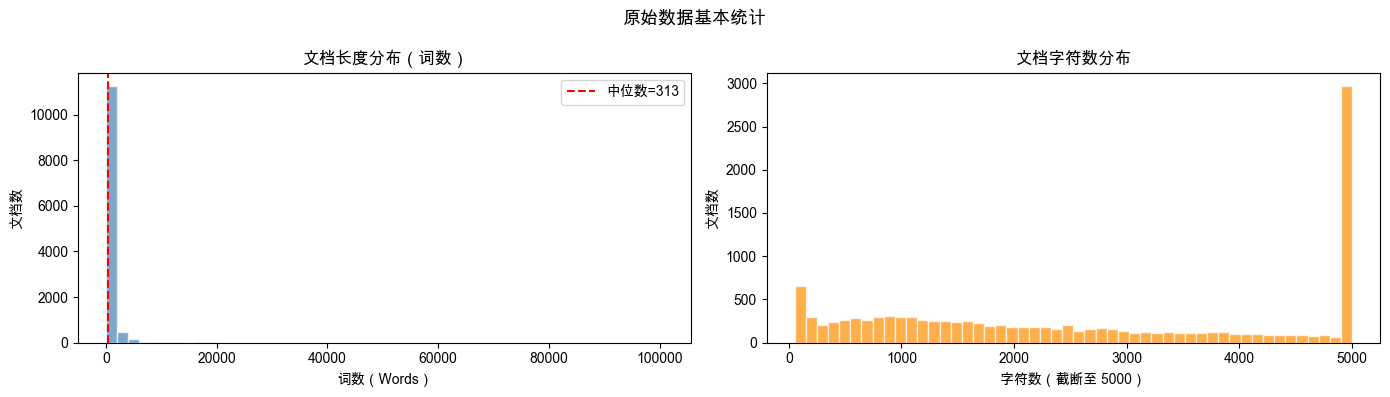

In [3]:
# === 文档长度分布统计与可视化 ===
# 计算每篇文档的词数和字符数，输出 P10/P50/P90 分位数
# 绘制两幅直方图：词数分布 + 字符数分布（字符数截断至 5000 以聚焦主体）
# 红色虚线标注中位数位置，帮助快速判断数据偏态
# 图片保存到 results/figures/ 供后续报告引用

texts = [d['text'] for d in docs]
urls = [d.get('url', '') for d in docs]
word_counts = [len(t.split()) for t in texts]
char_counts = [len(t) for t in texts]

print("📊 文档统计:")
print(f"  总文档数: {len(docs):,}")
print(f"  词数 中位数: {np.median(word_counts):.0f} | P10: {np.percentile(word_counts,10):.0f} | P90: {np.percentile(word_counts,90):.0f}")
print(f"  字符数 中位数: {np.median(char_counts):.0f}")
print(f"  总词数: {sum(word_counts):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(word_counts, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('词数（Words）')
axes[0].set_ylabel('文档数')
axes[0].set_title('文档长度分布（词数）')
axes[0].axvline(np.median(word_counts), color='red', linestyle='--', label=f'中位数={np.median(word_counts):.0f}')
axes[0].legend()

axes[1].hist([min(c, 5000) for c in char_counts], bins=50, color='darkorange', alpha=0.7, edgecolor='white')
axes[1].set_xlabel('字符数（截断至 5000）')
axes[1].set_ylabel('文档数')
axes[1].set_title('文档字符数分布')

plt.suptitle('原始数据基本统计', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/01_raw_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

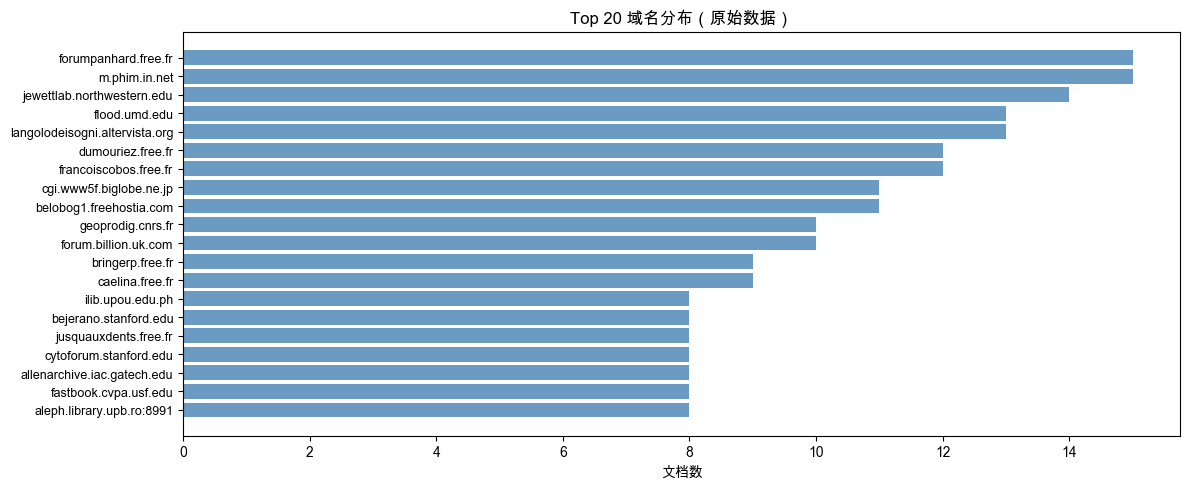

唯一域名总数: 10,334


In [4]:
# === 域名分布分析 ===
# 从 URL 中提取域名（去掉 www. 前缀），统计各域名出现频次
# 绘制 Top 20 域名的水平条形图，直观展示数据来源集中度
# 域名分布越均匀，说明数据多样性越好；过度集中在少数域名可能导致偏差
# 唯一域名总数是衡量来源多样性的重要指标

from urllib.parse import urlparse
import re

domains = []
for url in urls:
    try:
        domain = urlparse(url).netloc
        domain = re.sub(r'^www\.', '', domain.lower())
        if domain:
            domains.append(domain)
    except:
        pass

domain_counter = Counter(domains)
top_domains = domain_counter.most_common(20)

fig, ax = plt.subplots(figsize=(12, 5))
domain_names = [d[0][:30] for d in top_domains]
domain_counts = [d[1] for d in top_domains]
bars = ax.barh(range(len(top_domains)), domain_counts, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(top_domains)))
ax.set_yticklabels(domain_names, fontsize=9)
ax.set_xlabel('文档数')
ax.set_title('Top 20 域名分布（原始数据）', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../results/figures/01_domain_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"唯一域名总数: {len(domain_counter):,}")

In [5]:
# === 脏数据案例展示 ===
# 筛选词数 < 20 的短文档，随机采样 5 条展示
# 短文档通常是导航碎片、cookie 提示、空页面等低质量内容
# 这些案例直观说明"为什么需要数据过滤"——原始数据中混杂大量噪声
# 固定 seed=42 保证每次运行采样结果一致，方便对比

print("=" * 60)
print("  脏数据典型案例（随机采样短文档）")
print("=" * 60)
short_docs = [t for t in texts if len(t.split()) < 20]
import random
random.seed(42)
for i, text in enumerate(random.sample(short_docs[:100], min(5, len(short_docs[:100])))):
    print(f"案例 {i+1}（{len(text.split())} 词）:")
    print(f"  {repr(text[:200])}")

  脏数据典型案例（随机采样短文档）


案例 1（11 词）:
  'One moment, please...\nPlease wait while your request is being verified...'
案例 2（16 词）:
  'Account Suspended\nAccount Suspended\nThis Account has been suspended.\nContact your hosting provider for more information.'
案例 3（11 词）:
  'One moment, please...\nPlease wait while your request is being verified...'
案例 4（10 词）:
  'DocbWeb® - Exportação ISO2709\nNão existem resultados seleccionados para exportação'
案例 5（11 词）:
  'One moment, please...\nPlease wait while your request is being verified...'


## Cell Group B: HTML 提取器对比实验

> **为什么提取器的选择至关重要？**
>
> Nemotron-CC 发现从 Justext 换到 Trafilatura 后，高质量 token 数量显著增加。
> 这是一个经常被忽视但影响很大的“上游决策”——
> 在数据进入任何过滤器之前，提取质量就决定了上限。
>
> **两个提取器的核心区别：**
> - **Trafilatura**：专注于正文提取，会分析 HTML 结构（article, main 标签等），过滤导航栏/页脚
> - **Justext**：基于段落级别的统计规则，将段落分类为“near-boilerplate” vs “good content”
>
> **哪个更好？** 取决于数据类型。Trafilatura 在新闻/博客上更准；Justext 在混合内容页面上有时更保守（更少误杀）。FineWeb 和 Nemotron-CC 都选择了 Trafilatura。

In [6]:
# === HTML 提取器对比实验：Trafilatura vs Justext ===
# 从 WARC 文件中取 20 个 HTML 样本，分别用两个提取器提取正文
# 对比指标：平均提取词数、空文档率（提取失败率）
# - Trafilatura：基于 HTML 结构分析（article/main 标签），适合新闻/博客
# - Justext：基于段落级统计规则，将段落分为 boilerplate vs good content
# 如果依赖库未安装或无 WARC 文件，自动降级为模拟演示

try:
    import trafilatura
    import justext
    EXTRACTORS_AVAILABLE = True
except ImportError as e:
    print(f"⚠️ 提取器未安装: {e}")
    print("安装方式: pip install trafilatura justext3")
    EXTRACTORS_AVAILABLE = False

if EXTRACTORS_AVAILABLE and warc_files:
    from warcio.archiveiterator import ArchiveIterator

    html_samples = []
    with open(warc_files[0], 'rb') as f:
        for record in ArchiveIterator(f):
            if record.rec_type == 'response':
                content = record.content_stream().read()
                if b'<html' in content.lower()[:1000]:
                    html_samples.append(content)
                if len(html_samples) >= 20:
                    break

    print(f"收集到 {len(html_samples)} 个 HTML 样本进行对比")

    trafilatura_texts = []
    justext_texts = []

    for html in html_samples:
        # Trafilatura
        t = trafilatura.extract(html, include_tables=False, include_images=False)
        trafilatura_texts.append(t or '')

        # Justext
        try:
            paragraphs = justext.justext(html, justext.get_stoplist('English'))
            j = '\n'.join(p.text for p in paragraphs if not p.is_boilerplate)
            justext_texts.append(j)
        except:
            justext_texts.append('')

    # 对比统计
    tra_lens = [len(t.split()) for t in trafilatura_texts]
    jus_lens = [len(t.split()) for t in justext_texts]

    print(f"📊 提取器对比:")
    print(f"  Trafilatura 平均词数: {np.mean(tra_lens):.0f}")
    print(f"  Justext     平均词数: {np.mean(jus_lens):.0f}")
    print(f"  Trafilatura 空文档率: {sum(1 for t in trafilatura_texts if not t)/len(trafilatura_texts):.1%}")
    print(f"  Justext     空文档率: {sum(1 for t in justext_texts if not t)/len(justext_texts):.1%}")

else:
    print("⚠️ 使用模拟数据展示提取器对比原理")
    print("实际对比需要 WARC 文件 + trafilatura + justext3 库")

⚠️ 使用模拟数据展示提取器对比原理
实际对比需要 WARC 文件 + trafilatura + justext3 库


## Cell Group C: 建立基准线

> **为什么要在过滤前建立基准线？**
>
> 基准线是衡量每一代 pipeline 效果的零点。
> 如果原始数据 quality_score 均值是 0.30，
> 第一代过滤后是 0.45，第二代是 0.65——
> 这才有意义。没有基准线，“分数提升了”是空话。

In [7]:
# === 多样性基准线计算 ===
# 在任何过滤操作之前，先对原始数据计算多样性指标作为"零点"
# 核心指标：
# - N-gram unique ratio：unigram/bigram/trigram 的去重比率，越高说明词汇越丰富
# - 域名 Shannon Entropy：衡量来源分布均匀度，归一化后 1.0 = 完全均匀
# - 文档长度中位数：反映数据的典型规模
# 后续每一代 pipeline 都会重新计算这些指标，与此基准线对比来量化改进效果

print("📊 建立基准线（原始数据）...")
print("注意：质量分类器需要先训练，此处展示评估体系的初始化")

from src.evaluation.diversity_metrics import compute_diversity_report

# 多样性基准线（不需要额外模型）
diversity_baseline = compute_diversity_report(
    texts=texts[:run_cfg.get('eval_sample_size', 200)],
    urls=urls[:run_cfg.get('eval_sample_size', 200)],
    sample_size=min(200, len(texts)),
)

print("📐 多样性基准线:")
for ng_name, ng_stats in diversity_baseline.get('ngram_diversity', {}).items():
    print(f"  {ng_name} unique ratio: {ng_stats.get('unique_ratio', 0):.4f}")

if 'domain_entropy' in diversity_baseline:
    de = diversity_baseline['domain_entropy']
    print(f"  域名 Shannon Entropy: {de.get('entropy', 0):.4f} (归一化: {de.get('normalized_entropy', 0):.4f})")
    print(f"  唯一域名数: {de.get('n_domains', 0):,}")

print(f"文档长度中位数: {diversity_baseline.get('length_distribution', {}).get('median', 0):.0f} 词")

📊 建立基准线（原始数据）...
注意：质量分类器需要先训练，此处展示评估体系的初始化
  📐 计算多样性指标（共 500 条文档）...
     N-gram 多样性...


     长度分布...
     域名分布熵...
📐 多样性基准线:
  unigram unique ratio: 0.2913
  bigram unique ratio: 0.6147
  trigram unique ratio: 0.7706
  域名 Shannon Entropy: 5.6067 (归一化: 0.9934)
  唯一域名数: 496
文档长度中位数: 345 词


In [8]:
# === Token 数量基准线 + 基准线持久化 ===
# 使用 tokenizer 计算每篇文档的 token 数（采样 100 条估算均值）
# token 数是衡量数据集"实际训练价值"的核心指标（比词数更准确）
# 同时估算全量运行时的总 token 数，帮助预估训练成本
# 最后将所有基准线指标保存为 JSON，供后续 notebook 加载对比

from src.utils.tokenizer_utils import count_tokens_batch, get_tokenizer

tokenizer = get_tokenizer()
sample_tokens = count_tokens_batch(texts[:100], tokenizer)
avg_tokens = np.mean(sample_tokens)
estimated_total = int(avg_tokens * len(texts))

print(f"📊 Token 基准线（采样 100 条）:")
print(f"  平均 tokens/文档: {avg_tokens:.0f}")
print(f"  估算总 token 数: {estimated_total:,}")
print(f"  估算对应 full_run ({run_cfg.get('doc_limit', 50000):,} 文档): {int(avg_tokens * run_cfg.get('doc_limit', 50000)):,}")

# 保存基准线到 results
import json
baseline = {
    'doc_count': len(docs),
    'avg_tokens_per_doc': float(avg_tokens),
    'estimated_total_tokens': estimated_total,
    'diversity': diversity_baseline,
}
Path('../results/quality_scores').mkdir(parents=True, exist_ok=True)
with open('../results/quality_scores/baseline_metrics.json', 'w') as f:
    json.dump(baseline, f, ensure_ascii=False, indent=2)
print(f"✅ 基准线已保存: results/quality_scores/baseline_metrics.json")

📊 Token 基准线（采样 100 条）:
  平均 tokens/文档: 3879
  估算总 token 数: 46,550,640
  估算对应 full_run (12,000 文档): 46,550,640
✅ 基准线已保存: results/quality_scores/baseline_metrics.json
